# E. coli medium comparison using COBRApy

This notebook applies Flux Balance Analysis (FBA) to an E. coli genome-scale metabolic model under different medium conditions.

The goal is to compare how the predicted metabolic behavior changes when the model remains the same but the environmental condition changes.

Common element:
- same organism/model

Variable element:
- medium condition / carbon source / oxygen availability

In [9]:
from pathlib import Path

import cobra
from cobra.io import load_model
from cobra.flux_analysis import find_blocked_reactions

import pandas as pd
import matplotlib.pyplot as plt

In [10]:
output_dir = Path("outputs")
tables_dir = output_dir / "tables"
figures_dir = output_dir / "figures"

for folder in [output_dir, tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folders are ready.")

Output folders are ready.


In [11]:
model = load_model("iML1515")

print("Model ID:", model.id)
print("Number of reactions:", len(model.reactions))
print("Number of metabolites:", len(model.metabolites))
print("Number of genes:", len(model.genes))
print("Objective:", model.objective)

Model ID: iML1515
Number of reactions: 2712
Number of metabolites: 1877
Number of genes: 1516
Objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685


In [12]:
solution = model.optimize()

print("Solution status:", solution.status)
print("Objective value:", solution.objective_value)

Solution status: optimal
Objective value: 0.87699721425716


In [13]:
exchange_ids = [reaction.id for reaction in model.exchanges]

print("Number of exchange reactions:", len(exchange_ids))
exchange_ids[:50]

Number of exchange reactions: 331


['EX_pi_e',
 'EX_co2_e',
 'EX_met__L_e',
 'EX_metsox_S__L_e',
 'EX_acgam_e',
 'EX_cellb_e',
 'EX_crn_e',
 'EX_hxan_e',
 'EX_ile__L_e',
 'EX_chol_e',
 'EX_fe3_e',
 'EX_lac__L_e',
 'EX_leu__L_e',
 'EX_glcn_e',
 'EX_no3_e',
 'EX_h_e',
 'EX_orn_e',
 'EX_gln__L_e',
 'EX_pro__L_e',
 'EX_glyc_e',
 'EX_man_e',
 'EX_ade_e',
 'EX_mn2_e',
 'EX_4abut_e',
 'EX_ac_e',
 'EX_akg_e',
 'EX_ala__L_e',
 'EX_arg__L_e',
 'EX_asp__L_e',
 'EX_pyr_e',
 'EX_succ_e',
 'EX_thymd_e',
 'EX_rib__D_e',
 'EX_tyr__L_e',
 'EX_cytd_e',
 'EX_dcyt_e',
 'EX_fum_e',
 'EX_sbt__D_e',
 'EX_glu__L_e',
 'EX_gua_e',
 'EX_btn_e',
 'EX_ptrc_e',
 'EX_spmd_e',
 'EX_thym_e',
 'EX_xtsn_e',
 'EX_fe2_e',
 'EX_glc__D_e',
 'EX_alltn_e',
 'EX_ura_e',
 'EX_val__L_e']

In [14]:
required_exchanges = [
    "EX_glc__D_e",  # D-glucose
    "EX_o2_e",     # oxygen
    "EX_ac_e",     # acetate
    "EX_glyc_e",   # glycerol
    "EX_nh4_e",    # ammonium
    "EX_pi_e",     # phosphate
    "EX_h2o_e",    # water
    "EX_h_e",      # proton
    "EX_k_e",      # potassium
    "EX_na1_e",    # sodium
    "EX_so4_e",    # sulfate
    "EX_cl_e",     # chloride
    "EX_mg2_e",    # magnesium
    "EX_ca2_e",    # calcium
    "EX_fe2_e",    # iron II
    "EX_fe3_e"     # iron III
]

for reaction_id in required_exchanges:
    if reaction_id in model.reactions:
        print(reaction_id, "FOUND")
    else:
        print(reaction_id, "NOT FOUND")

EX_glc__D_e FOUND
EX_o2_e FOUND
EX_ac_e FOUND
EX_glyc_e FOUND
EX_nh4_e FOUND
EX_pi_e FOUND
EX_h2o_e FOUND
EX_h_e FOUND
EX_k_e FOUND
EX_na1_e FOUND
EX_so4_e FOUND
EX_cl_e FOUND
EX_mg2_e FOUND
EX_ca2_e FOUND
EX_fe2_e FOUND
EX_fe3_e FOUND


In [15]:
def close_all_exchanges(model):
    """
    Close all exchange reactions by setting their lower bound to 0.

    In COBRA models, negative lower bounds usually allow uptake.
    Setting lower_bound = 0 prevents uptake from the environment.
    """
    for reaction in model.exchanges:
        reaction.lower_bound = 0

In [16]:
def set_medium_condition(model, carbon_source, oxygen=True, carbon_uptake=10):
    """
    Set a defined medium condition for an E. coli COBRA model.
    """

    close_all_exchanges(model)

    basic_medium = {
        "EX_nh4_e": -1000,
        "EX_pi_e": -1000,
        "EX_h2o_e": -1000,
        "EX_h_e": -1000,
        "EX_k_e": -1000,
        "EX_na1_e": -1000,
        "EX_so4_e": -1000,
        "EX_cl_e": -1000,
        "EX_mg2_e": -1000,
        "EX_ca2_e": -1000,
        "EX_fe2_e": -1000,
        "EX_fe3_e": -1000
    }

    basic_medium[carbon_source] = -carbon_uptake

    if oxygen:
        basic_medium["EX_o2_e"] = -1000
    else:
        basic_medium["EX_o2_e"] = 0

    missing_reactions = []

    for reaction_id, lower_bound in basic_medium.items():
        if reaction_id in model.reactions:
            model.reactions.get_by_id(reaction_id).lower_bound = lower_bound
        else:
            missing_reactions.append(reaction_id)

    if missing_reactions:
        print("Missing exchange reactions:", missing_reactions)

    return model

In [17]:
test_model = model.copy()

set_medium_condition(
    test_model,
    carbon_source="EX_glc__D_e",
    oxygen=True,
    carbon_uptake=10
)

test_solution = test_model.optimize()

print("Status:", test_solution.status)
print("Objective value:", test_solution.objective_value)

Status: optimal
Objective value: 6.173157713866879e-17


In [18]:
default_medium = model.medium

print("Number of metabolites allowed in default medium:", len(default_medium))
default_medium

Number of metabolites allowed in default medium: 24


{'EX_pi_e': 1000.0,
 'EX_co2_e': 1000.0,
 'EX_fe3_e': 1000.0,
 'EX_h_e': 1000.0,
 'EX_mn2_e': 1000.0,
 'EX_fe2_e': 1000.0,
 'EX_glc__D_e': 10.0,
 'EX_zn2_e': 1000.0,
 'EX_mg2_e': 1000.0,
 'EX_ca2_e': 1000.0,
 'EX_ni2_e': 1000.0,
 'EX_cu2_e': 1000.0,
 'EX_sel_e': 1000.0,
 'EX_cobalt2_e': 1000.0,
 'EX_h2o_e': 1000.0,
 'EX_mobd_e': 1000.0,
 'EX_so4_e': 1000.0,
 'EX_nh4_e': 1000.0,
 'EX_k_e': 1000.0,
 'EX_na1_e': 1000.0,
 'EX_cl_e': 1000.0,
 'EX_o2_e': 1000.0,
 'EX_tungs_e': 1000.0,
 'EX_slnt_e': 1000.0}

In [19]:
def set_medium_from_default(base_model, carbon_source, oxygen=True, carbon_uptake=10):
    """
    Set medium condition using the model's default medium as a base.

    This keeps the essential nutrients already defined in the model
    and changes only the carbon source and oxygen availability.
    """

    model_condition = base_model.copy()

    # Start from the model's default medium
    medium = model_condition.medium.copy()

    # Remove common carbon sources if present
    carbon_sources_to_remove = [
        "EX_glc__D_e",
        "EX_ac_e",
        "EX_glyc_e",
        "EX_succ_e",
        "EX_fru_e",
        "EX_lac__D_e",
        "EX_lac__L_e"
    ]

    for source in carbon_sources_to_remove:
        if source in medium:
            medium[source] = 0

    # Add selected carbon source
    medium[carbon_source] = carbon_uptake

    # Set oxygen availability
    if oxygen:
        medium["EX_o2_e"] = 1000
    else:
        medium["EX_o2_e"] = 0

    # Apply medium
    model_condition.medium = medium

    return model_condition

In [20]:
test_model = set_medium_from_default(
    base_model=model,
    carbon_source="EX_glc__D_e",
    oxygen=True,
    carbon_uptake=10
)

test_solution = test_model.optimize()

print("Status:", test_solution.status)
print("Objective value:", test_solution.objective_value)

Status: optimal
Objective value: 0.8769972144269725


In [21]:
test_model = set_medium_from_default(
    base_model=model,
    carbon_source="EX_glc__D_e",
    oxygen=False,
    carbon_uptake=10
)

test_solution = test_model.optimize()

print("Status:", test_solution.status)
print("Objective value:", test_solution.objective_value)

Status: optimal
Objective value: 0.1575398169375829


In [22]:
test_model = set_medium_from_default(
    base_model=model,
    carbon_source="EX_ac_e",
    oxygen=True,
    carbon_uptake=10
)

test_solution = test_model.optimize()

print("Status:", test_solution.status)
print("Objective value:", test_solution.objective_value)

Status: optimal
Objective value: 0.21009920466535056


In [23]:
test_model = set_medium_from_default(
    base_model=model,
    carbon_source="EX_glyc_e",
    oxygen=True,
    carbon_uptake=10
)

test_solution = test_model.optimize()

print("Status:", test_solution.status)
print("Objective value:", test_solution.objective_value)

Status: optimal
Objective value: 0.4947134924179063


In [24]:
conditions = {
    "glucose_aerobic": {
        "carbon_source": "EX_glc__D_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "glucose_anaerobic": {
        "carbon_source": "EX_glc__D_e",
        "oxygen": False,
        "carbon_uptake": 10
    },
    "acetate_aerobic": {
        "carbon_source": "EX_ac_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "glycerol_aerobic": {
        "carbon_source": "EX_glyc_e",
        "oxygen": True,
        "carbon_uptake": 10
    }
}

In [25]:
def analyze_condition(base_model, condition_name, carbon_source, oxygen, carbon_uptake=10):
    """
    Apply one medium condition, run FBA, extract summary metrics and save flux table.
    """

    model_condition = set_medium_from_default(
        base_model=base_model,
        carbon_source=carbon_source,
        oxygen=oxygen,
        carbon_uptake=carbon_uptake
    )

    solution = model_condition.optimize()

    flux_df = solution.fluxes.reset_index()
    flux_df.columns = ["reaction_id", "flux"]
    flux_df["absolute_flux"] = flux_df["flux"].abs()
    flux_df = flux_df.sort_values("absolute_flux", ascending=False)

    nonzero_fluxes = int((solution.fluxes.abs() > 1e-9).sum())
    zero_fluxes = int((solution.fluxes.abs() <= 1e-9).sum())

    blocked_reactions = find_blocked_reactions(model_condition)
    num_blocked = len(blocked_reactions)
    blocked_fraction = num_blocked / len(model_condition.reactions)

    summary = {
        "model_id": model_condition.id,
        "condition": condition_name,
        "carbon_source": carbon_source,
        "oxygen_available": oxygen,
        "carbon_uptake": carbon_uptake,
        "solution_status": solution.status,
        "objective_value": solution.objective_value,
        "num_reactions": len(model_condition.reactions),
        "num_metabolites": len(model_condition.metabolites),
        "num_genes": len(model_condition.genes),
        "num_nonzero_fluxes": nonzero_fluxes,
        "num_zero_fluxes": zero_fluxes,
        "num_blocked_reactions": num_blocked,
        "blocked_reaction_fraction": blocked_fraction
    }

    safe_name = f"{model_condition.id}_{condition_name}"

    flux_df.to_csv(tables_dir / f"{safe_name}_fluxes.csv", index=False)

    blocked_df = pd.DataFrame({"blocked_reaction_id": blocked_reactions})
    blocked_df.to_csv(tables_dir / f"{safe_name}_blocked_reactions.csv", index=False)

    return summary, flux_df

In [26]:
all_summaries = []
all_flux_tables = {}

for condition_name, params in conditions.items():
    print("=" * 60)
    print("Running condition:", condition_name)

    summary, flux_df = analyze_condition(
        base_model=model,
        condition_name=condition_name,
        carbon_source=params["carbon_source"],
        oxygen=params["oxygen"],
        carbon_uptake=params["carbon_uptake"]
    )

    all_summaries.append(summary)
    all_flux_tables[condition_name] = flux_df

comparison_df = pd.DataFrame(all_summaries)

comparison_df

Running condition: glucose_aerobic
Running condition: glucose_anaerobic
Running condition: acetate_aerobic
Running condition: glycerol_aerobic


,model_id,condition,carbon_source,oxygen_available,carbon_uptake,solution_status,objective_value,num_reactions,num_metabolites,num_genes,num_nonzero_fluxes,num_zero_fluxes,num_blocked_reactions,blocked_reaction_fraction
0,iML1515,glucose_aerobic,EX_glc__D_e,True,10,optimal,0.876997,2712,1877,1516,431,2281,968,0.356932
1,iML1515,glucose_anaerobic,EX_glc__D_e,False,10,optimal,0.157540,2712,1877,1516,435,2277,1042,0.384218
2,iML1515,acetate_aerobic,EX_ac_e,True,10,optimal,0.210099,2712,1877,1516,433,2279,973,0.358776
3,iML1515,glycerol_aerobic,EX_glyc_e,True,10,optimal,0.494713,2712,1877,1516,431,2281,973,0.358776


In [27]:
summary_path = tables_dir / f"{model.id}_medium_comparison_summary.csv"

comparison_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: outputs\tables\iML1515_medium_comparison_summary.csv


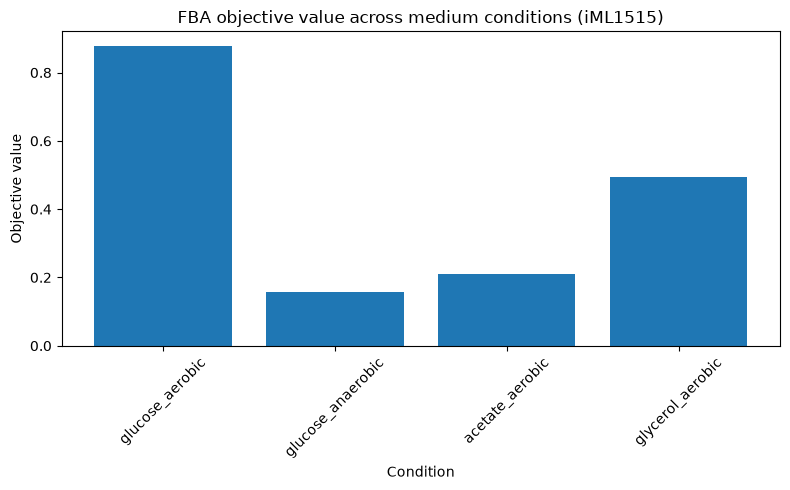

Saved: outputs\figures\iML1515_objective_value_by_condition.png


In [28]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["condition"], comparison_df["objective_value"])
plt.xlabel("Condition")
plt.ylabel("Objective value")
plt.title(f"FBA objective value across medium conditions ({model.id})")
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = figures_dir / f"{model.id}_objective_value_by_condition.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved:", figure_path)

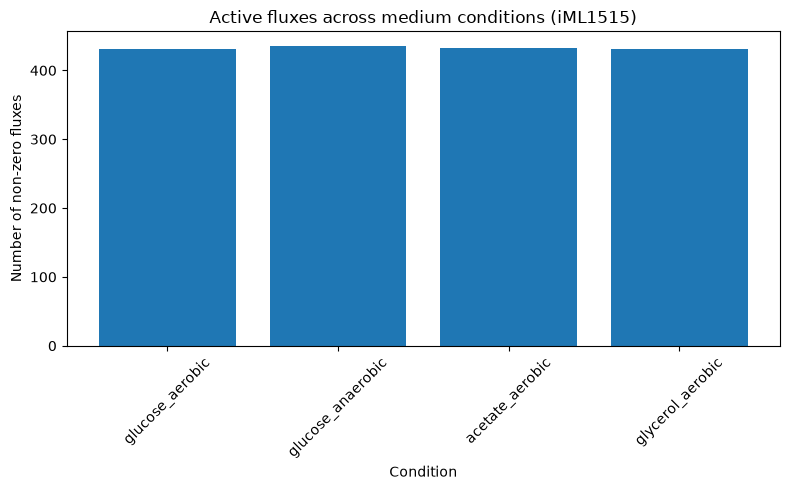

Saved: outputs\figures\iML1515_active_fluxes_by_condition.png


In [29]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["condition"], comparison_df["num_nonzero_fluxes"])
plt.xlabel("Condition")
plt.ylabel("Number of non-zero fluxes")
plt.title(f"Active fluxes across medium conditions ({model.id})")
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = figures_dir / f"{model.id}_active_fluxes_by_condition.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved:", figure_path)

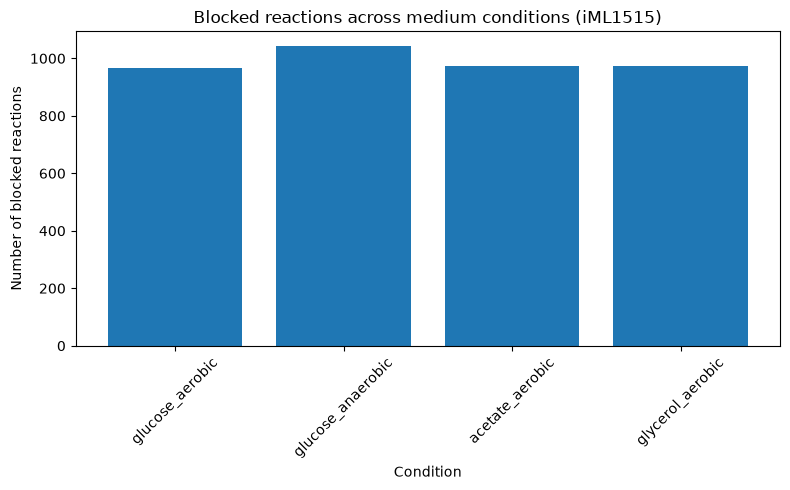

Saved: outputs\figures\iML1515_blocked_reactions_by_condition.png


In [30]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["condition"], comparison_df["num_blocked_reactions"])
plt.xlabel("Condition")
plt.ylabel("Number of blocked reactions")
plt.title(f"Blocked reactions across medium conditions ({model.id})")
plt.xticks(rotation=45)
plt.tight_layout()

figure_path = figures_dir / f"{model.id}_blocked_reactions_by_condition.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved:", figure_path)

In [31]:
report_table = comparison_df[
    [
        "condition",
        "carbon_source",
        "oxygen_available",
        "objective_value",
        "num_nonzero_fluxes",
        "num_blocked_reactions",
        "blocked_reaction_fraction"
    ]
].copy()

report_table["objective_value"] = report_table["objective_value"].round(4)
report_table["blocked_reaction_fraction"] = report_table["blocked_reaction_fraction"].round(4)

report_table

,condition,carbon_source,oxygen_available,objective_value,num_nonzero_fluxes,num_blocked_reactions,blocked_reaction_fraction
0,glucose_aerobic,EX_glc__D_e,True,0.8770,431,968,0.3569
1,glucose_anaerobic,EX_glc__D_e,False,0.1575,435,1042,0.3842
2,acetate_aerobic,EX_ac_e,True,0.2101,433,973,0.3588
3,glycerol_aerobic,EX_glyc_e,True,0.4947,431,973,0.3588


In [32]:
for condition_name, flux_df in all_flux_tables.items():
    print("=" * 80)
    print("Top 10 absolute fluxes for:", condition_name)
    display(flux_df.head(10))

Top 10 absolute fluxes for: glucose_aerobic


,reaction_id,flux,absolute_flux
798,ATPS4rpp,70.432494,70.432494
1362,H2Otpp,-47.162365,47.162365
724,H2Otex,-47.162365,47.162365
1424,EX_h2o_e,47.162365,47.162365
1871,CYTBO3_4pp,44.256288,44.256288
2230,NADH16pp,37.997044,37.997044
1364,CO2tex,-24.003293,24.003293
45,EX_co2_e,24.003293,24.003293
806,CO2tpp,-24.003293,24.003293
846,O2tex,22.131763,22.131763


Top 10 absolute fluxes for: glucose_anaerobic


,reaction_id,flux,absolute_flux
717,Htex,-28.612477,28.612477
92,EX_h_e,28.612477,28.612477
140,PGK,-19.620952,19.620952
601,GAPD,19.620952,19.620952
126,ENO,19.358865,19.358865
1868,PGM,-19.358865,19.358865
69,PFL,18.244798,18.244798
1854,FORtex,-18.227718,18.227718
1007,FORtppi,18.227718,18.227718
216,EX_for_e,18.227718,18.227718


Top 10 absolute fluxes for: acetate_aerobic


,reaction_id,flux,absolute_flux
798,ATPS4rpp,32.508183,32.508183
1871,CYTBO3_4pp,21.854340,21.854340
1362,H2Otpp,-16.924532,16.924532
724,H2Otex,-16.924532,16.924532
1424,EX_h2o_e,16.924532,16.924532
2230,NADH16pp,14.946687,14.946687
806,CO2tpp,-11.376393,11.376393
1364,CO2tex,-11.376393,11.376393
45,EX_co2_e,11.376393,11.376393
1981,EX_o2_e,-10.928037,10.928037


Top 10 absolute fluxes for: glycerol_aerobic


,reaction_id,flux,absolute_flux
798,ATPS4rpp,44.399395,44.399395
724,H2Otex,-32.758299,32.758299
1362,H2Otpp,-32.758299,32.758299
1424,EX_h2o_e,32.758299,32.758299
1871,CYTBO3_4pp,27.273027,27.273027
2230,NADH16pp,24.581291,24.581291
1981,EX_o2_e,-13.638555,13.638555
734,O2tpp,13.638555,13.638555
846,O2tex,13.638555,13.638555
99,EX_glyc_e,-10.000000,10.000000


In [33]:
def get_internal_fluxes(flux_df):
    """
    Remove exchange and common transport/boundary reactions
    to focus on internal metabolic reactions.
    """

    excluded_patterns = [
        "EX_",      # exchange reactions
        "tex",      # outer membrane transport
        "tpp",      # periplasm transport
        "t2pp",
        "t3pp",
        "t4pp",
        "abcpp",
        "DM_",      # demand reactions
        "SK_"       # sink reactions
    ]

    internal_df = flux_df.copy()

    for pattern in excluded_patterns:
        internal_df = internal_df[
            ~internal_df["reaction_id"].str.contains(pattern, case=False, regex=False)
        ]

    return internal_df

In [34]:
internal_top_flux_tables = []

for condition_name, flux_df in all_flux_tables.items():
    internal_df = get_internal_fluxes(flux_df)
    top10_internal = internal_df.head(10).copy()
    top10_internal["condition"] = condition_name

    internal_top_flux_tables.append(top10_internal)

    print("=" * 80)
    print("Top 10 internal absolute fluxes for:", condition_name)
    display(top10_internal)

internal_top_fluxes_combined = pd.concat(internal_top_flux_tables, ignore_index=True)

internal_top_fluxes_combined = internal_top_fluxes_combined[
    ["condition", "reaction_id", "flux", "absolute_flux"]
]

Top 10 internal absolute fluxes for: glucose_aerobic


,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,70.432494,70.432494,glucose_aerobic
1871,CYTBO3_4pp,44.256288,44.256288,glucose_aerobic
2230,NADH16pp,37.997044,37.997044,glucose_aerobic
140,PGK,-17.105434,17.105434,glucose_aerobic
601,GAPD,17.105434,17.105434,glucose_aerobic
1868,PGM,-15.598898,15.598898,glucose_aerobic
126,ENO,15.598898,15.598898,glucose_aerobic
1414,GLCptspp,10.000000,10.000000,glucose_aerobic
1496,PDH,9.689687,9.689687,glucose_aerobic
1861,PFK,8.451764,8.451764,glucose_aerobic


Top 10 internal absolute fluxes for: glucose_anaerobic


,reaction_id,flux,absolute_flux,condition
140,PGK,-19.620952,19.620952,glucose_anaerobic
601,GAPD,19.620952,19.620952,glucose_anaerobic
126,ENO,19.358865,19.358865,glucose_anaerobic
1868,PGM,-19.358865,19.358865,glucose_anaerobic
69,PFL,18.244798,18.244798,glucose_anaerobic
137,PGI,10.000000,10.000000,glucose_anaerobic
1414,GLCptspp,10.000000,10.000000,glucose_anaerobic
127,FBA,9.862871,9.862871,glucose_anaerobic
1861,PFK,9.862871,9.862871,glucose_anaerobic
1878,TPI,9.840680,9.840680,glucose_anaerobic


Top 10 internal absolute fluxes for: acetate_aerobic


,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,32.508183,32.508183,acetate_aerobic
1871,CYTBO3_4pp,21.854340,21.854340,acetate_aerobic
2230,NADH16pp,14.946687,14.946687,acetate_aerobic
192,MDH,10.683360,10.683360,acetate_aerobic
80,ACKr,10.122317,10.122317,acetate_aerobic
77,PTAr,-10.122317,10.122317,acetate_aerobic
893,ACt2rpp,10.000000,10.000000,acetate_aerobic
195,FUM,9.032382,9.032382,acetate_aerobic
11,CS,7.064271,7.064271,acetate_aerobic
1945,ACONTb,7.064271,7.064271,acetate_aerobic


Top 10 internal absolute fluxes for: glycerol_aerobic


,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,44.399395,44.399395,glycerol_aerobic
1871,CYTBO3_4pp,27.273027,27.273027,glycerol_aerobic
2230,NADH16pp,24.581291,24.581291,glycerol_aerobic
1878,TPI,9.499844,9.499844,glycerol_aerobic
140,PGK,-8.810064,8.810064,glycerol_aerobic
601,GAPD,8.810064,8.810064,glycerol_aerobic
126,ENO,7.960228,7.960228,glycerol_aerobic
1868,PGM,-7.960228,7.960228,glycerol_aerobic
1434,ATPM,6.860000,6.860000,glycerol_aerobic
508,GLYCDx,6.158009,6.158009,glycerol_aerobic


In [35]:
internal_top_fluxes_path = tables_dir / f"{model.id}_top10_internal_fluxes_all_conditions.csv"

internal_top_fluxes_combined.to_csv(internal_top_fluxes_path, index=False)

print("Saved:", internal_top_fluxes_path)

Saved: outputs\tables\iML1515_top10_internal_fluxes_all_conditions.csv


In [36]:
internal_top_reaction_counts = (
    internal_top_fluxes_combined
    .groupby("reaction_id")["condition"]
    .nunique()
    .reset_index()
    .rename(columns={"condition": "num_conditions_in_top10"})
    .sort_values("num_conditions_in_top10", ascending=False)
)

internal_top_reaction_counts

,reaction_id,num_conditions_in_top10
4,ATPS4rpp,3
6,CYTBO3_4pp,3
19,PGK,3
20,PGM,3
14,NADH16pp,3
10,GAPD,3
7,ENO,3
22,TPI,2
16,PFK,2
11,GLCptspp,2


In [37]:
internal_common_top_reactions_path = tables_dir / f"{model.id}_common_top_internal_reactions.csv"

internal_top_reaction_counts.to_csv(internal_common_top_reactions_path, index=False)

print("Saved:", internal_common_top_reactions_path)

Saved: outputs\tables\iML1515_common_top_internal_reactions.csv


In [38]:
candidate_carbon_sources = {
    "glucose": "EX_glc__D_e",
    "acetate": "EX_ac_e",
    "glycerol": "EX_glyc_e",
    "succinate": "EX_succ_e",
    "fructose": "EX_fru_e",
    "lactate_D": "EX_lac__D_e",
    "lactate_L": "EX_lac__L_e",
    "pyruvate": "EX_pyr_e",
    "mannose": "EX_man_e",
    "galactose": "EX_gal_e"
}

for name, reaction_id in candidate_carbon_sources.items():
    if reaction_id in model.reactions:
        print(name, reaction_id, "FOUND")
    else:
        print(name, reaction_id, "NOT FOUND")

glucose EX_glc__D_e FOUND
acetate EX_ac_e FOUND
glycerol EX_glyc_e FOUND
succinate EX_succ_e FOUND
fructose EX_fru_e FOUND
lactate_D EX_lac__D_e FOUND
lactate_L EX_lac__L_e FOUND
pyruvate EX_pyr_e FOUND
mannose EX_man_e FOUND
galactose EX_gal_e FOUND


In [39]:
carbon_test_results = []

for carbon_name, reaction_id in candidate_carbon_sources.items():
    test_model = set_medium_from_default(
        base_model=model,
        carbon_source=reaction_id,
        oxygen=True,
        carbon_uptake=10
    )

    test_solution = test_model.optimize()

    carbon_test_results.append({
        "carbon_name": carbon_name,
        "carbon_source": reaction_id,
        "oxygen_available": True,
        "solution_status": test_solution.status,
        "objective_value": test_solution.objective_value
    })

carbon_test_df = pd.DataFrame(carbon_test_results)

carbon_test_df.sort_values("objective_value", ascending=False)

,carbon_name,carbon_source,oxygen_available,solution_status,objective_value
8,mannose,EX_man_e,True,optimal,0.876997
0,glucose,EX_glc__D_e,True,optimal,0.876997
4,fructose,EX_fru_e,True,optimal,0.876997
9,galactose,EX_gal_e,True,optimal,0.867593
2,glycerol,EX_glyc_e,True,optimal,0.494713
3,succinate,EX_succ_e,True,optimal,0.450086
5,lactate_D,EX_lac__D_e,True,optimal,0.377356
6,lactate_L,EX_lac__L_e,True,optimal,0.350565
7,pyruvate,EX_pyr_e,True,optimal,0.313940
1,acetate,EX_ac_e,True,optimal,0.210099


In [40]:
carbon_test_path = tables_dir / f"{model.id}_aerobic_carbon_source_screening.csv"

carbon_test_df.to_csv(carbon_test_path, index=False)

print("Saved:", carbon_test_path)

Saved: outputs\tables\iML1515_aerobic_carbon_source_screening.csv


In [41]:
conditions = {
    "glucose_aerobic": {
        "carbon_source": "EX_glc__D_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "fructose_aerobic": {
        "carbon_source": "EX_fru_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "galactose_aerobic": {
        "carbon_source": "EX_gal_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "glycerol_aerobic": {
        "carbon_source": "EX_glyc_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "succinate_aerobic": {
        "carbon_source": "EX_succ_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "acetate_aerobic": {
        "carbon_source": "EX_ac_e",
        "oxygen": True,
        "carbon_uptake": 10
    },
    "glucose_anaerobic": {
        "carbon_source": "EX_glc__D_e",
        "oxygen": False,
        "carbon_uptake": 10
    }
}

In [42]:
all_summaries = []
all_flux_tables = {}

for condition_name, params in conditions.items():
    print("=" * 60)
    print("Running condition:", condition_name)

    summary, flux_df = analyze_condition(
        base_model=model,
        condition_name=condition_name,
        carbon_source=params["carbon_source"],
        oxygen=params["oxygen"],
        carbon_uptake=params["carbon_uptake"]
    )

    all_summaries.append(summary)
    all_flux_tables[condition_name] = flux_df

comparison_df = pd.DataFrame(all_summaries)

comparison_df

Running condition: glucose_aerobic
Running condition: fructose_aerobic
Running condition: galactose_aerobic
Running condition: glycerol_aerobic
Running condition: succinate_aerobic
Running condition: acetate_aerobic
Running condition: glucose_anaerobic


,model_id,condition,carbon_source,oxygen_available,carbon_uptake,solution_status,objective_value,num_reactions,num_metabolites,num_genes,num_nonzero_fluxes,num_zero_fluxes,num_blocked_reactions,blocked_reaction_fraction
0,iML1515,glucose_aerobic,EX_glc__D_e,True,10,optimal,0.876997,2712,1877,1516,431,2281,968,0.356932
1,iML1515,fructose_aerobic,EX_fru_e,True,10,optimal,0.876997,2712,1877,1516,432,2280,967,0.356563
2,iML1515,galactose_aerobic,EX_gal_e,True,10,optimal,0.867593,2712,1877,1516,436,2276,966,0.356195
3,iML1515,glycerol_aerobic,EX_glyc_e,True,10,optimal,0.494713,2712,1877,1516,431,2281,973,0.358776
4,iML1515,succinate_aerobic,EX_succ_e,True,10,optimal,0.450086,2712,1877,1516,429,2283,973,0.358776
5,iML1515,acetate_aerobic,EX_ac_e,True,10,optimal,0.210099,2712,1877,1516,433,2279,973,0.358776
6,iML1515,glucose_anaerobic,EX_glc__D_e,False,10,optimal,0.157540,2712,1877,1516,435,2277,1042,0.384218


In [43]:
summary_path = tables_dir / f"{model.id}_medium_comparison_summary.csv"

comparison_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: outputs\tables\iML1515_medium_comparison_summary.csv


Saved: outputs\figures\iML1515_objective_value_by_condition.png


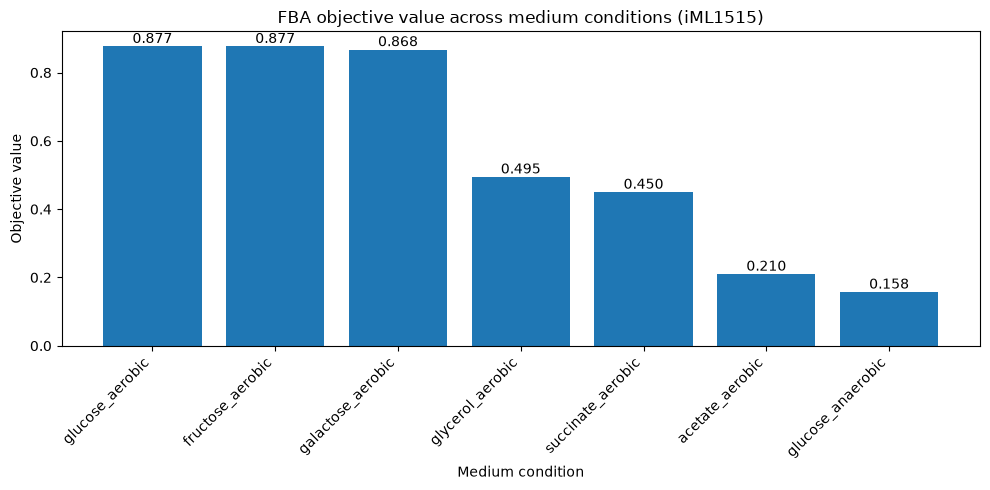

Saved: outputs\figures\iML1515_active_fluxes_by_condition.png


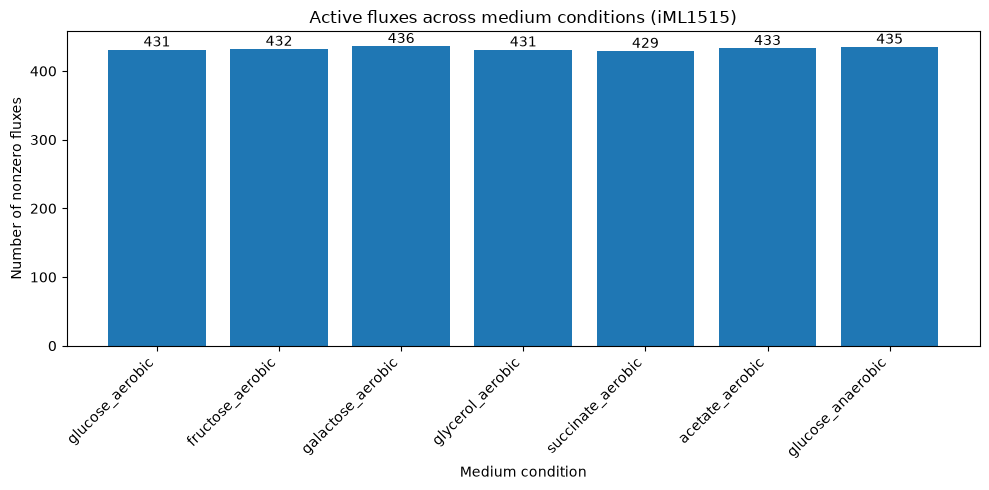

Saved: outputs\figures\iML1515_blocked_reactions_by_condition.png


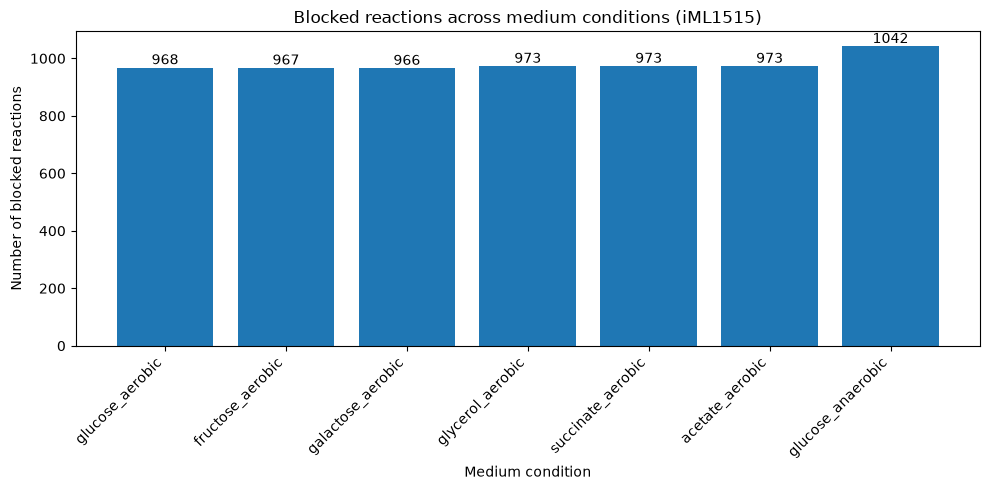

,model_id,condition,carbon_source,oxygen_available,carbon_uptake,solution_status,objective_value,num_reactions,num_metabolites,num_genes,num_nonzero_fluxes,num_zero_fluxes,num_blocked_reactions,blocked_reaction_fraction
0,iML1515,glucose_aerobic,EX_glc__D_e,True,10,optimal,0.876997,2712,1877,1516,431,2281,968,0.356932
1,iML1515,fructose_aerobic,EX_fru_e,True,10,optimal,0.876997,2712,1877,1516,432,2280,967,0.356563
2,iML1515,galactose_aerobic,EX_gal_e,True,10,optimal,0.867593,2712,1877,1516,436,2276,966,0.356195
3,iML1515,glycerol_aerobic,EX_glyc_e,True,10,optimal,0.494713,2712,1877,1516,431,2281,973,0.358776
4,iML1515,succinate_aerobic,EX_succ_e,True,10,optimal,0.450086,2712,1877,1516,429,2283,973,0.358776
5,iML1515,acetate_aerobic,EX_ac_e,True,10,optimal,0.210099,2712,1877,1516,433,2279,973,0.358776
6,iML1515,glucose_anaerobic,EX_glc__D_e,False,10,optimal,0.157540,2712,1877,1516,435,2277,1042,0.384218


In [44]:
plt.figure(figsize=(10, 5))

bars = plt.bar(comparison_df["condition"], comparison_df["objective_value"])

plt.bar_label(bars, fmt="%.3f")
plt.title(f"FBA objective value across medium conditions ({model.id})")
plt.xlabel("Medium condition")
plt.ylabel("Objective value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / f"{model.id}_objective_value_by_condition.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()


plt.figure(figsize=(10, 5))

bars = plt.bar(comparison_df["condition"], comparison_df["num_nonzero_fluxes"])

plt.bar_label(bars)
plt.title(f"Active fluxes across medium conditions ({model.id})")
plt.xlabel("Medium condition")
plt.ylabel("Number of nonzero fluxes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / f"{model.id}_active_fluxes_by_condition.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()

plt.figure(figsize=(10, 5))

bars = plt.bar(comparison_df["condition"], comparison_df["num_blocked_reactions"])

plt.bar_label(bars)
plt.title(f"Blocked reactions across medium conditions ({model.id})")
plt.xlabel("Medium condition")
plt.ylabel("Number of blocked reactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

figure_path = figures_dir / f"{model.id}_blocked_reactions_by_condition.png"
plt.savefig(figure_path, dpi=300)

print("Saved:", figure_path)
plt.show()


comparison_df


In [45]:
report_table = comparison_df[
    [
        "condition",
        "carbon_source",
        "oxygen_available",
        "objective_value",
        "num_nonzero_fluxes",
        "num_blocked_reactions",
        "blocked_reaction_fraction"
    ]
].copy()

report_table["objective_value"] = report_table["objective_value"].round(4)
report_table["blocked_reaction_fraction"] = report_table["blocked_reaction_fraction"].round(4)

report_table

,condition,carbon_source,oxygen_available,objective_value,num_nonzero_fluxes,num_blocked_reactions,blocked_reaction_fraction
0,glucose_aerobic,EX_glc__D_e,True,0.8770,431,968,0.3569
1,fructose_aerobic,EX_fru_e,True,0.8770,432,967,0.3566
2,galactose_aerobic,EX_gal_e,True,0.8676,436,966,0.3562
3,glycerol_aerobic,EX_glyc_e,True,0.4947,431,973,0.3588
4,succinate_aerobic,EX_succ_e,True,0.4501,429,973,0.3588
5,acetate_aerobic,EX_ac_e,True,0.2101,433,973,0.3588
6,glucose_anaerobic,EX_glc__D_e,False,0.1575,435,1042,0.3842


In [46]:
report_table_path = tables_dir / f"{model.id}_medium_comparison_report_table.csv"

report_table.to_csv(report_table_path, index=False)

print("Saved:", report_table_path)

Saved: outputs\tables\iML1515_medium_comparison_report_table.csv


In [47]:
internal_top_flux_tables = []

for condition_name, flux_df in all_flux_tables.items():
    internal_df = get_internal_fluxes(flux_df)
    top10_internal = internal_df.head(10).copy()
    top10_internal["condition"] = condition_name

    internal_top_flux_tables.append(top10_internal)

    print("=" * 80)
    print("Top 10 internal absolute fluxes for:", condition_name)
    display(top10_internal)

internal_top_fluxes_combined = pd.concat(internal_top_flux_tables, ignore_index=True)

internal_top_fluxes_combined = internal_top_fluxes_combined[
    ["condition", "reaction_id", "flux", "absolute_flux"]
]

Top 10 internal absolute fluxes for: glucose_aerobic


,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,70.432494,70.432494,glucose_aerobic
1871,CYTBO3_4pp,44.256288,44.256288,glucose_aerobic
2230,NADH16pp,37.997044,37.997044,glucose_aerobic
140,PGK,-17.105434,17.105434,glucose_aerobic
601,GAPD,17.105434,17.105434,glucose_aerobic
1868,PGM,-15.598898,15.598898,glucose_aerobic
126,ENO,15.598898,15.598898,glucose_aerobic
1414,GLCptspp,10.000000,10.000000,glucose_aerobic
1496,PDH,9.689687,9.689687,glucose_aerobic
1861,PFK,8.451764,8.451764,glucose_aerobic


Top 10 internal absolute fluxes for: fructose_aerobic


,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,70.432494,70.432494,fructose_aerobic
1871,CYTBO3_4pp,44.256288,44.256288,fructose_aerobic
2230,NADH16pp,37.997044,37.997044,fructose_aerobic
140,PGK,-17.105434,17.105434,fructose_aerobic
601,GAPD,17.105434,17.105434,fructose_aerobic
126,ENO,15.598898,15.598898,fructose_aerobic
1868,PGM,-15.598898,15.598898,fructose_aerobic
1496,PDH,9.689687,9.689687,fructose_aerobic
868,FRUptspp,8.451764,8.451764,fructose_aerobic
127,FBA,8.451764,8.451764,fructose_aerobic


Top 10 internal absolute fluxes for: galactose_aerobic


...

,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,48.268152,48.268152,succinate_aerobic
1871,CYTBO3_4pp,31.127352,31.127352,succinate_aerobic
2230,NADH16pp,17.776350,17.776350,succinate_aerobic
195,FUM,13.671937,13.671937,succinate_aerobic
1964,SUCDi,13.351734,13.351734,succinate_aerobic
192,MDH,11.393006,11.393006,succinate_aerobic
1434,ATPM,6.860000,6.860000,succinate_aerobic
1496,PDH,5.111549,5.111549,succinate_aerobic
1404,GLUDy,-3.848837,3.848837,succinate_aerobic
11,CS,3.686520,3.686520,succinate_aerobic


Top 10 internal absolute fluxes for: acetate_aerobic


,reaction_id,flux,absolute_flux,condition
798,ATPS4rpp,32.508183,32.508183,acetate_aerobic
1871,CYTBO3_4pp,21.854340,21.854340,acetate_aerobic
2230,NADH16pp,14.946687,14.946687,acetate_aerobic
192,MDH,10.683360,10.683360,acetate_aerobic
80,ACKr,10.122317,10.122317,acetate_aerobic
77,PTAr,-10.122317,10.122317,acetate_aerobic
893,ACt2rpp,10.000000,10.000000,acetate_aerobic
195,FUM,9.032382,9.032382,acetate_aerobic
11,CS,7.064271,7.064271,acetate_aerobic
1945,ACONTb,7.064271,7.064271,acetate_aerobic


Top 10 internal absolute fluxes for: glucose_anaerobic


,reaction_id,flux,absolute_flux,condition
140,PGK,-19.620952,19.620952,glucose_anaerobic
601,GAPD,19.620952,19.620952,glucose_anaerobic
126,ENO,19.358865,19.358865,glucose_anaerobic
1868,PGM,-19.358865,19.358865,glucose_anaerobic
69,PFL,18.244798,18.244798,glucose_anaerobic
137,PGI,10.000000,10.000000,glucose_anaerobic
1414,GLCptspp,10.000000,10.000000,glucose_anaerobic
127,FBA,9.862871,9.862871,glucose_anaerobic
1861,PFK,9.862871,9.862871,glucose_anaerobic
1878,TPI,9.840680,9.840680,glucose_anaerobic


In [48]:
internal_top_fluxes_path = tables_dir / f"{model.id}_top10_internal_fluxes_all_conditions.csv"

internal_top_fluxes_combined.to_csv(internal_top_fluxes_path, index=False)

print("Saved:", internal_top_fluxes_path)

Saved: outputs\tables\iML1515_top10_internal_fluxes_all_conditions.csv


In [49]:
internal_top_reaction_counts = (
    internal_top_fluxes_combined
    .groupby("reaction_id")["condition"]
    .nunique()
    .reset_index()
    .rename(columns={"condition": "num_conditions_in_top10"})
    .sort_values("num_conditions_in_top10", ascending=False)
)

internal_top_reaction_counts

,reaction_id,num_conditions_in_top10
4,ATPS4rpp,6
6,CYTBO3_4pp,6
17,NADH16pp,6
12,GAPD,5
7,ENO,5
22,PGK,5
23,PGM,5
18,PDH,3
19,PFK,2
8,FBA,2


In [50]:
internal_common_top_reactions_path = tables_dir / f"{model.id}_common_top_internal_reactions.csv"

internal_top_reaction_counts.to_csv(internal_common_top_reactions_path, index=False)

print("Saved:", internal_common_top_reactions_path)

Saved: outputs\tables\iML1515_common_top_internal_reactions.csv
